# COVID-19 Learning Loss in Bay Area Schools
## Can School Demographics Predict Which Schools Were Hit Hardest?

---

### Research Question
> **Can school-level demographic factors help predict which Bay Area schools experienced the most math learning loss between 2019 and 2023?**

### Background
Nationwide, 12th-grader math scores fell 3 points since 2019, and NAEP 2023 data shows 13-year-old math scores dropped 9 points from 2020. In California, the share of UCSD students needing remedial math jumped from 0.5% in Fall 2020 to 11.8% in Fall 2025. This project investigates whether pre-existing school demographics can explain which Bay Area schools were most affected.

### Data Sources
- **CAASPP Research Files** (California Dept. of Education): test results by school/grade/subgroup for 2019 and 2023
- **Entity Files**: school name, county, district, type
- **Lookup Tables**: `StudentGroups.txt` (demographic ID → name), `Tests.txt` (test ID → subject)

> **Note:** Testing was suspended in 2019–2020 due to COVID-19, and 2020–2021 testing was optional. We compare the 2019 pre-pandemic baseline to the 2023 recovery state.

---

## 1. Data Loading

### 1.1 Imports

In [6]:
import pandas as pd

### 1.2 Pre-COVID Data (2019)
The 2019 CAASPP file uses comma (`,`) as delimiter and cp1252 encoding.

In [7]:
caaspp_2019_df = pd.read_csv("sb_ca2019_all_csv_v4.txt", sep=",", dtype=str, encoding="cp1252", engine="python", on_bad_lines="skip")
caaspp_2019_df.to_csv("pre_df.csv", index=False)
caaspp_2019_df

,County Code,District Code,School Code,Filler,Test Year,Subgroup ID,Test Type,Total Tested At Entity Level,Total Tested with Scores,Grade,...,Area 1 Percentage Below Standard,Area 2 Percentage Above Standard,Area 2 Percentage Near Standard,Area 2 Percentage Below Standard,Area 3 Percentage Above Standard,Area 3 Percentage Near Standard,Area 3 Percentage Below Standard,Area 4 Percentage Above Standard,Area 4 Percentage Near Standard,Area 4 Percentage Below Standard
0,00,00000,0000000,NaN,2019,1,B,3165580,3162910,3,...,28.01,20.83,49.66,29.50,21.89,61.25,16.86,24.14,48.16,27.70
1,00,00000,0000000,NaN,2019,3,B,1616938,1615465,3,...,31.09,17.93,49.03,33.04,20.66,60.54,18.81,22.66,46.69,30.65
2,00,00000,0000000,NaN,2019,4,B,1548642,1547445,3,...,24.81,23.85,50.32,25.83,23.17,61.99,14.84,25.68,49.69,24.63
3,00,00000,0000000,NaN,2019,6,B,2651676,2649540,3,...,21.24,25.12,51.92,22.96,26.17,61.23,12.60,28.93,49.45,21.62
4,00,00000,0000000,NaN,2019,7,B,132465,132405,3,...,8.70,42.74,47.23,10.03,42.25,53.14,4.60,47.75,43.21,9.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3576486,58,72769,5838305,NaN,2019,222,B,*,*,13,...,*,*,*,*,*,*,*,*,*,*
3576487,58,72769,5838305,NaN,2019,223,B,*,*,13,...,*,*,*,*,*,*,*,*,*,*
3576488,58,72769,5838305,NaN,2019,224,B,19,19,13,...,57.89,0.00,63.16,36.84,5.26,57.89,36.84,0.00,0.00,0.00
3576489,58,72769,5838305,NaN,2019,226,B,54,54,13,...,55.56,16.67,44.44,38.89,14.81,57.41,27.78,0.00,0.00,0.00


In [8]:
entities_2019_df = pd.read_csv("sb_ca2019entities_csv.txt", dtype=str, encoding="cp1252", engine="python")
entities_2019_df.to_csv("pre_df_entities.csv", index=False)
entities_2019_df

,County Code,District Code,School Code,Filler,Test Year,Type Id,County Name,District Name,School Name,Zip Code
0,37,68056,0114686,NaN,2019,7,San Diego,Del Mar Union Elementary,Ocean Air,92130
1,37,68056,6038111,NaN,2019,7,San Diego,Del Mar Union Elementary,Del Mar Heights Elementary,92014
2,37,68056,6088983,NaN,2019,7,San Diego,Del Mar Union Elementary,Del Mar Hills Elementary,92014
3,37,68056,6110696,NaN,2019,7,San Diego,Del Mar Union Elementary,Carmel Del Mar Elementary,92130
4,37,68056,6115620,NaN,2019,7,San Diego,Del Mar Union Elementary,Ashley Falls Elementary,92130
...,...,...,...,...,...,...,...,...,...,...
11384,37,68049,0138313,NaN,2019,9,San Diego,University Prep,University Prep,91764
11385,37,68049,6038095,NaN,2019,7,San Diego,Dehesa Elementary,Dehesa Elementary,92019
11386,37,68049,6119564,NaN,2019,9,San Diego,Dehesa Charter,Dehesa Charter,92026
11387,37,68056,0000000,NaN,2019,6,San Diego,Del Mar Union Elementary,NaN,


### 1.3 Post-COVID Data (2023)
The 2023 CAASPP file uses caret (`^`) as delimiter

In [9]:
caaspp_2023_df = pd.read_csv("sb_ca2023_all_csv_v1.txt", sep="^", dtype=str)
caaspp_2023_df.to_csv("post_df.csv", index=False)
caaspp_2023_df

,County Code,District Code,School Code,Filler,Test Year,Student Group ID,Test Type,Total Tested at Reporting Level,Total Tested with Scores at Reporting Level,Grade,...,Area 2 Percentage Above Standard,Area 2 Percentage Near Standard,Area 2 Percentage Below Standard,Area 3 Percentage Above Standard,Area 3 Percentage Near Standard,Area 3 Percentage Below Standard,Area 4 Percentage Above Standard,Area 4 Percentage Near Standard,Area 4 Percentage Below Standard,Type ID
0,00,00000,0000000,NaN,2023,1,B,2960990,2957491,3,...,16.18,50.24,33.58,11.75,70.96,17.29,16.07,60.00,23.94,4
1,00,00000,0000000,NaN,2023,3,B,1512977,1511175,3,...,13.96,49.35,36.69,11.47,70.55,17.99,15.20,59.33,25.47,4
2,00,00000,0000000,NaN,2023,4,B,1445927,1444241,3,...,18.48,51.16,30.36,12.04,71.39,16.57,16.96,60.69,22.35,4
3,00,00000,0000000,NaN,2023,6,B,2459254,2456394,3,...,19.88,52.83,27.29,14.03,71.81,14.16,19.54,61.39,19.08,4
4,00,00000,0000000,NaN,2023,7,B,144219,144145,3,...,28.50,54.52,16.98,19.43,71.38,9.19,28.13,60.23,11.65,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4052589,58,72769,5838305,NaN,2023,226,B,24,24,13,...,*,*,*,*,*,*,*,*,*,7
4052590,58,72769,5838305,NaN,2023,227,B,8,8,13,...,*,*,*,*,*,*,*,*,*,7
4052591,58,72769,5838305,NaN,2023,241,B,244,243,13,...,15.23,64.20,20.58,12.76,66.67,20.58,0.00,0.00,0.00,7
4052592,58,72769,5838305,NaN,2023,250,B,8,8,13,...,*,*,*,*,*,*,*,*,*,7


In [10]:
entities_2023_df = pd.read_csv("sb_ca2023entities_csv.txt", sep="^", dtype=str, encoding="cp1252", engine="python")
entities_2023_df.to_csv("post_df_entities.csv", index=False)
entities_2023_df

,County Code,District Code,School Code,Filler,Test Year,Type ID,County Name,District Name,School Name,Zip Code
0,00,00000,0000000,NaN,2023,4,State of California,NaN,NaN,NaN
1,01,00000,0000000,NaN,2023,5,Alameda,NaN,NaN,NaN
2,01,10017,0000000,NaN,2023,6,Alameda,Alameda County Office of Education,NaN,NaN
3,01,10017,0112607,NaN,2023,9,Alameda,Envision Academy for Arts & Technology,Envision Academy for Arts & Technology,94612
4,01,10017,0123968,NaN,2023,9,Alameda,Community School for Creative Education,Community School for Creative Education,94606
...,...,...,...,...,...,...,...,...,...,...
11297,58,72751,6118806,NaN,2023,10,Yuba,Wheatland,Wheatland Charter Academy,95903
11298,58,72769,0000000,NaN,2023,6,Yuba,Wheatland Union High,NaN,NaN
11299,58,72769,0123570,NaN,2023,7,Yuba,Wheatland Union High,Wheatland Community Day High,95692
11300,58,72769,0133751,NaN,2023,7,Yuba,Wheatland Union High,Edward P. Duplex,95692


### 1.4 Lookup Tables
`StudentGroups.txt` maps numeric demographic IDs to human-readable names.
`Tests.txt` maps test IDs to subjects (Test ID 2 = Mathematics).

In [11]:
studentgroup_df = pd.read_csv("StudentGroups.txt", sep="^", dtype=str, encoding="cp1252", engine="python")
studentgroup_df.to_csv("pre_df_features.csv", index=False)
studentgroup_df

,Demographic ID,Demographic ID Num,Demographic Name,Student Group
0,001,1,All Students,All Students
1,128,128,Reported disabilities,Disability Status
2,099,99,No reported disabilities,Disability Status
3,031,31,Socioeconomically disadvantaged,Economic Status
4,111,111,Not socioeconomically disadvantaged,Economic Status
5,006,6,"IFEP, RFEP, and EO (Fluent English proficient ...",English-Language Fluency
6,007,7,IFEP (Initial fluent English proficient),English-Language Fluency
7,008,8,RFEP (Reclassified fluent English proficient),English-Language Fluency
8,120,120,ELs enrolled less than 12 months,English-Language Fluency
9,142,142,ELs enrolled 12 months or more,English-Language Fluency


In [12]:
tests_df = pd.read_csv("Tests.txt", sep="^", dtype=str, encoding="cp1252", engine="python")
tests_df

,Test ID,Test ID Num,Test Name
0,1,1,SB - English Language Arts/Literacy
1,2,2,SB - Mathematics
2,3,3,CAA - English Language Arts/Literacy
3,4,4,CAA - Mathematics
4,17,17,CAST - California Science Test
5,18,18,CAA - Science
6,39,39,CSA - California Spanish Assessment


---
## 2. Data Cleaning & Feature Engineering

### 2.1 Filter to Bay Area Counties
We restrict to the 9 Bay Area counties. County codes are pulled from the 2023 entity file (more complete coverage).

In [39]:
bay_area_counties = ['Alameda', 'Contra Costa', 'Marin', 'Napa', 'San Francisco', 'San Mateo', 'Santa Clara', 'Solano', 'Sonoma']
bay_area_county_codes = entities_2023_df[entities_2023_df["County Name"].isin(bay_area_counties)]["County Code"].unique()

pre_bay_df = caaspp_2019_df[caaspp_2019_df["County Code"].isin(bay_area_county_codes)].copy()
post_bay_df = caaspp_2023_df[caaspp_2023_df["County Code"].isin(bay_area_county_codes)].copy()

print(f"2019 Bay Area rows: {len(pre_bay_df):,}")
print(f"2023 Bay Area rows: {len(post_bay_df):,}")

2019 Bay Area rows: 637,148
2023 Bay Area rows: 708,780


### 2.2 Extract Mathematics Results
Test ID `2` = Mathematics. Note: the column name differs between years (`Test Id` vs `Test ID`)

In [40]:
pre_bay_math_df = pre_bay_df[pre_bay_df["Test Id"] == "2"].copy()
post_bay_math_df = post_bay_df[post_bay_df["Test ID"] == "2"].copy()

print(f"2019 math rows: {len(pre_bay_math_df):,} | unique schools: {pre_bay_math_df['School Code'].nunique()}")
print(f"2023 math rows: {len(post_bay_math_df):,} | unique schools: {post_bay_math_df['School Code'].nunique()}")

2019 math rows: 318,584 | unique schools: 1853
2023 math rows: 354,421 | unique schools: 1815


### 2.3 Create Unique School Identifiers
School codes are not unique across districts. We concatenate County + District + School codes into a 14-digit identifier.

In [41]:
for df_ in [pre_bay_math_df, post_bay_math_df, entities_2019_df, entities_2023_df]:
    df_["School Identifier"] = df_["County Code"] + df_["District Code"] + df_["School Code"]

pre_bay_math_df[["County Code", "District Code", "School Code", "School Identifier"]].drop_duplicates().head()

,County Code,District Code,School Code,School Identifier
1224,01,00000,0000000,01000000000000
1762,01,10017,0000000,01100170000000
1966,01,10017,0112607,01100170112607
2275,01,10017,0123968,01100170123968
2716,01,10017,0124172,01100170124172


### 2.4 Align Column Names and Combine 2019 & 2023
The 2023 file uses different column names for the same fields. We rename to match 2019, then keep only shared columns before concatenating.

In [42]:
pre_df = pre_bay_math_df.copy()
post_df = post_bay_math_df.copy()

# Rename 2023 columns to match 2019 naming convention
post_df = post_df.rename(columns={
    "Student Group ID": "Subgroup ID",
    "Students Enrolled": "CAASPP Reported Enrollment",
    "Total Tested at Reporting Level": "Total Tested At Entity Level",
    "Total Tested with Scores at Reporting Level": "Total Tested with Scores"
})
pre_df = pre_df.rename(columns={"Test Id": "Test ID"})

# Keep only columns present in both years
common_cols = list(set(pre_df.columns).intersection(set(post_df.columns)))
pre_clean_df = pre_df[common_cols].copy()
post_clean_df = post_df[common_cols].copy()

combined_df = pd.concat([pre_clean_df, post_clean_df], ignore_index=True)
print(f"Combined rows: {len(combined_df):,} | Unique schools: {combined_df['School Identifier'].nunique()}")

Combined rows: 673,005 | Unique schools: 2104


### 2.5 Select Relevant Columns and Fix Data Types
We keep only the columns needed for feature engineering. Subgroup ID and numeric fields are cast to their correct types.

In [43]:
combined_df = combined_df[[
    "School Identifier", "Test Year", "Subgroup ID",
    "Percentage Standard Met and Above", "Students Tested"
]].copy()

combined_df["Subgroup ID"] = combined_df["Subgroup ID"].astype(int)
combined_df["Percentage Standard Met and Above"] = pd.to_numeric(combined_df["Percentage Standard Met and Above"], errors="coerce")
combined_df["Students Tested"] = pd.to_numeric(combined_df["Students Tested"], errors="coerce")

### 2.6 Compute Subgroup Percentages
For each school and year, we calculate the share of tested students in each demographic subgroup.
This normalizes for school size so features represent composition, not raw headcounts.

We use Subgroup ID 1 ("All Students") as the denominator, averaged across grades to get one total per school-year.

In [44]:
# Get one total-students value per school per year (average across grade-level rows)
total_students = (
    combined_df[combined_df["Subgroup ID"] == 1]
    .groupby(["School Identifier", "Test Year"])["Students Tested"]
    .mean()
    .reset_index()
    .rename(columns={"Students Tested": "Total_Students"})
)

combined_df = combined_df.merge(total_students, on=["School Identifier", "Test Year"], how="left")
combined_df["Subgroup Percentage"] = combined_df["Students Tested"] / combined_df["Total_Students"]
combined_df

,School Identifier,Test Year,Subgroup ID,Percentage Standard Met and Above,Students Tested,Total_Students,Subgroup Percentage
0,01000000000000,2019,1,57.88,16884.0,29049.75,0.581210
1,01000000000000,2019,3,58.69,8582.0,29049.75,0.295424
2,01000000000000,2019,4,57.04,8302.0,29049.75,0.285786
3,01000000000000,2019,6,66.96,13143.0,29049.75,0.452431
4,01000000000000,2019,7,87.50,1168.0,29049.75,0.040207
...,...,...,...,...,...,...,...
673000,49753906060222,2023,240,NaN,NaN,135.00,NaN
673001,49753906060222,2023,241,34.57,269.0,135.00,1.992593
673002,49753906060222,2023,250,0.00,23.0,135.00,0.170370
673003,49753906060222,2023,251,NaN,NaN,135.00,NaN


### 2.7 Build Demographic Pivot Table
Each row = one school. Each column = `{year}_{subgroup_id}` = percentage of that demographic group in that year.

In [47]:
demo_pivot = combined_df.pivot_table(
    values="Subgroup Percentage",
    index="School Identifier",
    columns=["Test Year", "Subgroup ID"],
    aggfunc="mean"
)

#flatten multi-level column names to "year_subgroupid" format
demo_pivot.columns = [f"{year}_{subgroup}" for (year, subgroup) in demo_pivot.columns]
demo_pivot = demo_pivot.reset_index()
demo_pivot

,School Identifier,2019_1,2019_3,2019_4,2019_6,2019_7,2019_8,2019_28,2019_31,2019_50,...,2023_224,2023_225,2023_226,2023_227,2023_240,2023_241,2023_243,2023_250,2023_251,2023_252
0,01000000000000,1.0,0.513163,0.486837,0.833028,0.073219,0.242119,0.004750,0.438291,0.00327,...,0.091285,0.002898,0.120541,0.052799,0.000885,0.999115,NaN,0.062632,0.042712,0.618240
1,01100170000000,1.0,0.428571,0.571429,0.828571,NaN,NaN,NaN,0.600000,NaN,...,0.000000,0.000000,NaN,0.000000,NaN,0.978022,NaN,0.181319,NaN,0.582418
2,01100170112607,1.0,0.488095,0.511905,0.928571,NaN,0.452381,NaN,0.797619,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.406250,0.000000,0.625000
3,01100170123968,1.0,0.488889,0.511111,0.637037,NaN,0.254074,NaN,0.407407,NaN,...,0.282552,NaN,NaN,NaN,NaN,1.000000,NaN,0.205078,0.246094,0.309896
4,01100170124172,1.0,0.478448,0.521552,0.991379,0.216236,0.205172,NaN,0.201149,NaN,...,0.108451,NaN,0.108451,0.225352,NaN,1.000000,NaN,NaN,NaN,0.805634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993,49753904930251,1.0,1.000000,NaN,0.800000,NaN,NaN,NaN,0.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.333333
1994,49753904932554,1.0,0.542857,0.457143,0.971429,NaN,0.495238,0.057143,0.552381,NaN,...,0.126214,NaN,0.271845,NaN,NaN,1.000000,NaN,NaN,NaN,0.533981
1995,49753904975390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.833333
1996,49753906051791,1.0,0.570312,0.429688,0.531250,NaN,0.335938,0.101562,0.875000,NaN,...,0.104712,NaN,0.214660,NaN,NaN,1.000000,NaN,NaN,0.129145,0.460733


### 2.8 Build Math Score Pivot Table and Compute Learning Loss
`Learning_Loss = score_2023 − score_2019`. A negative value means the school's math proficiency declined.

In [48]:
#use Subgroup ID 1 (all students) for school-level math performance
math_df = combined_df[combined_df["Subgroup ID"] == 1][[
    "School Identifier", "Test Year", "Percentage Standard Met and Above"
]]

math_pivot = math_df.pivot_table(
    index="School Identifier",
    columns="Test Year",
    values="Percentage Standard Met and Above"
)

math_pivot["Learning_Loss"] = math_pivot["2023"] - math_pivot["2019"]
math_pivot

Test Year,2019,2023,Learning_Loss
School Identifier,,,
01000000000000,48.906250,46.658750,-2.247500
01100170000000,0.000000,0.000000,0.000000
01100170112607,10.710000,16.020000,5.310000
01100170123968,16.188571,11.032857,-5.155714
01100170124172,93.592857,90.644286,-2.948571
...,...,...,...
49753900124230,63.300000,NaN,NaN
49753904930251,NaN,0.000000,NaN
49753904932554,20.000000,25.240000,5.240000


### 2.9 Merge Pivot Tables
We merge demographics and math scores on School Identifier (inner join = only schools with both 2019 and 2023 data).
We then drop 2023 demographic columns to avoid data leakage (we wouldn't know post-pandemic demographics before predicting.)

In [49]:
df = demo_pivot.merge(
    math_pivot[["Learning_Loss", "2019"]],
    on="School Identifier",
    how="inner"
)

#drop 2023 demographic columns (data leakage risk)
col_2023 = [col for col in df.columns if col.startswith("2023_")]
df = df.drop(columns=col_2023)

print(f"Final dataset: {len(df)} schools")
df

Final dataset: 1925 schools


,School Identifier,2019_1,2019_3,2019_4,2019_6,2019_7,2019_8,2019_28,2019_31,2019_50,...,2019_220,2019_221,2019_222,2019_223,2019_224,2019_225,2019_226,2019_227,Learning_Loss,2019
0,01000000000000,1.0,0.513163,0.486837,0.833028,0.073219,0.242119,0.004750,0.438291,0.00327,...,0.026764,0.001248,0.201361,0.029708,0.102178,0.003821,0.145922,0.047969,-2.247500,48.906250
1,01100170000000,1.0,0.428571,0.571429,0.828571,NaN,NaN,NaN,0.600000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
2,01100170112607,1.0,0.488095,0.511905,0.928571,NaN,0.452381,NaN,0.797619,NaN,...,0.095238,NaN,NaN,NaN,0.071429,NaN,NaN,NaN,5.310000,10.710000
3,01100170123968,1.0,0.488889,0.511111,0.637037,NaN,0.254074,NaN,0.407407,NaN,...,0.311111,NaN,0.181481,NaN,0.281481,NaN,0.103704,NaN,-5.155714,16.188571
4,01100170124172,1.0,0.478448,0.521552,0.991379,0.216236,0.205172,NaN,0.201149,NaN,...,NaN,NaN,0.413793,NaN,0.090517,NaN,0.135776,0.353448,-2.948571,93.592857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,49753900124230,1.0,0.466165,0.533835,0.924812,NaN,0.210526,NaN,0.413534,NaN,...,NaN,NaN,NaN,NaN,0.135338,NaN,0.511278,NaN,NaN,63.300000
1921,49753904930251,1.0,1.000000,NaN,0.800000,NaN,NaN,NaN,0.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1922,49753904932554,1.0,0.542857,0.457143,0.971429,NaN,0.495238,0.057143,0.552381,NaN,...,NaN,NaN,NaN,NaN,0.142857,NaN,0.266667,NaN,5.240000,20.000000
1923,49753906051791,1.0,0.570312,0.429688,0.531250,NaN,0.335938,0.101562,0.875000,NaN,...,NaN,NaN,NaN,NaN,0.109375,NaN,0.078125,NaN,19.547500,38.200000


---
## 3. Feature Selection

We select 15 demographic subgroups covering disability status, economic status, English language fluency, race/ethnicity, and gender.

**Exclusion criteria:**
- Subgroups missing in more than 40% of schools
- Subgroups that are near-duplicates of already included features

| Feature | Demographic Group | Category |
|---|---|---|
| `2019_128` | Reported Disabilities | Disability |
| `2019_99` | No Reported Disabilities | Disability |
| `2019_31` | Socioeconomically Disadvantaged | Economic |
| `2019_111` | Not Socioeconomically Disadvantaged | Economic |
| `2019_6` | Fluent English Proficient | English Fluency |
| `2019_160` | English Learner (excl. RFEP) | English Fluency |
| `2019_180` | English Only | English Fluency |
| `2019_76` | Asian | Race/Ethnicity |
| `2019_74` | Black or African American | Race/Ethnicity |
| `2019_78` | Hispanic or Latino | Race/Ethnicity |
| `2019_80` | White | Race/Ethnicity |
| `2019_224` | Hispanic or Latino (Not Socioec. Disadvantaged) | Intersectional |
| `2019_226` | White (Not Socioec. Disadvantaged) | Intersectional |
| `2019_4` | Female | Gender |
| `2019_3` | Male | Gender |

In [50]:
studentgroup_df["Demographic ID Num"] = studentgroup_df["Demographic ID Num"].astype(int)

selected_features = [128, 99, 31, 111, 6, 160, 180, 76, 74, 78, 80, 224, 226, 4, 3]
studentgroup_df[studentgroup_df["Demographic ID Num"].isin(selected_features)]

,Demographic ID,Demographic ID Num,Demographic Name,Student Group
1,128,128,Reported disabilities,Disability Status
2,099,99,No reported disabilities,Disability Status
3,031,31,Socioeconomically disadvantaged,Economic Status
4,111,111,Not socioeconomically disadvantaged,Economic Status
5,006,6,"IFEP, RFEP, and EO (Fluent English proficient ...",English-Language Fluency
10,160,160,"EL (English learner, excluding RFEP)",English-Language Fluency
12,180,180,EO (English only),English-Language Fluency
19,076,76,Asian,Race and Ethnicity
20,074,74,Black or African American,Race and Ethnicity
22,078,78,Hispanic or Latino,Race and Ethnicity


In [51]:
df = df[[
    "School Identifier",
    "2019_128", "2019_99",           #disability status
    "2019_31",  "2019_111",          #economic status
    "2019_6",   "2019_160", "2019_180",  #english fluency
    "2019_76",  "2019_74",  "2019_78", "2019_80",  #Race/ethnicity
    "2019_224", "2019_226",          #intersectional
    "2019_4",   "2019_3",            #gender
    "2019",                          #Pre-COVID baseline math score
    "Learning_Loss"                  #Target variable
]]
print(f"Shape: {df.shape}")
df

Shape: (1925, 18)


,School Identifier,2019_128,2019_99,2019_31,2019_111,2019_6,2019_160,2019_180,2019_76,2019_74,2019_78,2019_80,2019_224,2019_226,2019_4,2019_3,2019,Learning_Loss
0,01000000000000,0.105526,0.894474,0.438291,0.561709,0.833028,0.166112,0.517689,0.263806,0.092867,0.346629,0.173676,0.102178,0.145922,0.486837,0.513163,48.906250,-2.247500
1,01100170000000,0.257143,0.742857,0.600000,0.400000,0.828571,0.228571,0.828571,NaN,0.428571,0.342857,NaN,NaN,NaN,0.571429,0.428571,0.000000,0.000000
2,01100170112607,0.119048,0.880952,0.797619,0.202381,0.928571,0.071429,0.440476,NaN,0.345238,0.535714,0.047619,0.071429,NaN,0.511905,0.488095,10.710000,5.310000
3,01100170123968,0.278704,0.814815,0.407407,0.592593,0.637037,0.340741,0.437037,0.259259,0.220370,0.562963,0.129630,0.281481,0.103704,0.511111,0.488889,16.188571,-5.155714
4,01100170124172,0.120690,0.931034,0.201149,0.892241,0.991379,NaN,0.646552,0.465517,0.075431,0.105603,0.135776,0.090517,0.135776,0.521552,0.478448,93.592857,-2.948571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1920,49753900124230,0.112782,0.924812,0.413534,0.586466,0.924812,0.112782,0.706767,NaN,NaN,0.398496,0.586466,0.135338,0.511278,0.533835,0.466165,63.300000,NaN
1921,49753904930251,NaN,1.000000,0.800000,NaN,0.800000,NaN,NaN,NaN,NaN,0.800000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
1922,49753904932554,0.104762,0.895238,0.552381,0.447619,0.971429,NaN,0.466667,NaN,NaN,0.600000,0.352381,0.142857,0.266667,0.457143,0.542857,20.000000,5.240000
1923,49753906051791,0.179688,0.820312,0.875000,0.151042,0.531250,0.468750,0.195312,NaN,NaN,0.882812,0.125000,0.109375,0.078125,0.429688,0.570312,38.200000,19.547500


---
## 4. Exploratory Data Analysis

### 4.1 Distribution of Learning Loss

How many schools declined vs improved, and by how much?

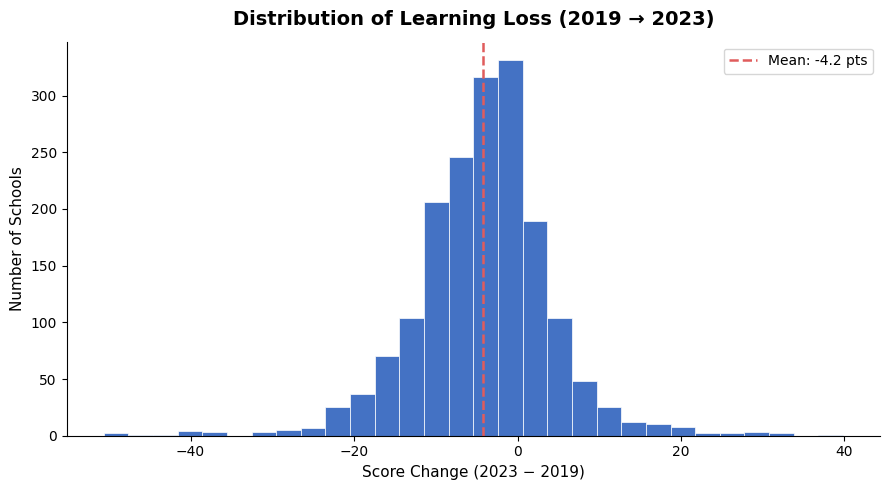

Schools with lower scores post-pandemic: 65.7%
Mean learning loss:   -4.19 points
Median learning loss: -3.88 points


In [52]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Learning_Loss"].dropna(), bins=30, color="#4472C4", edgecolor="white", linewidth=0.5)
mean_loss = df["Learning_Loss"].dropna().mean()
ax.axvline(mean_loss, color="#E05C5C", linestyle="--", linewidth=1.8, label=f"Mean: {mean_loss:.1f} pts")
ax.set_title("Distribution of Learning Loss (2019 → 2023)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Score Change (2023 − 2019)", fontsize=11)
ax.set_ylabel("Number of Schools", fontsize=11)
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("learning_loss_distribution.png", dpi=150)
plt.show()

pct_declined = (df["Learning_Loss"] < 0).mean() * 100
print(f"Schools with lower scores post-pandemic: {pct_declined:.1f}%")
print(f"Mean learning loss:   {mean_loss:.2f} points")
print(f"Median learning loss: {df['Learning_Loss'].dropna().median():.2f} points")

---
## 5. Modeling

### 5.1 Preprocessing
Drop rows with missing `Learning_Loss` (target cannot be imputed), then median-impute remaining demographic NaNs.

In [53]:
df = df.dropna(subset="Learning_Loss")
df = df.fillna(df.median(numeric_only=True))
print(f"Modeling dataset: {len(df)} schools")

Modeling dataset: 1767 schools


### 5.2 Train / Test Split & Model Training

We compare four regression models. 80/20 train-test split with `random_state=42` for reproducibility.

In [55]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import numpy as np

X = df.drop(columns=["Learning_Loss", "School Identifier"])
y = df["Learning_Loss"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models
models = {
  "Linear Regression":  LinearRegression(),
  "Random Forest":      RandomForestRegressor(n_estimators=500, min_samples_split=5, min_samples_leaf=2, max_features=0.7, random_state=42),
  "XGBoost":            XGBRegressor(n_estimators=500, learning_rate=0.01, max_depth=3, subsample=0.8, colsample_bytree=0.8, min_child_weight=5, random_state=42),
  "Gradient Boost":     GradientBoostingRegressor(n_estimators=500, learning_rate=0.01, max_depth=3, subsample=0.8, min_samples_leaf=5, random_state=42),
}

# Train and evaluate each model
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({
        "Model": name,
        "R2":   round(r2_score(y_test, pred), 4),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, pred)), 4),
        "MAE":  round(mean_absolute_error(y_test, pred), 4),
    })

results_df = pd.DataFrame(results)
print("=== Test Set Performance ===")
print(results_df.to_string(index=False))

# 5-fold cross validation
cv_results = []
for name, model in models.items():
    cv_r2  = cross_val_score(model, X, y, cv=5, scoring="r2").mean()
    cv_mae = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_absolute_error").mean()
    cv_results.append({"Model": name, "CV_R2": round(cv_r2, 4), "CV_MAE": round(cv_mae, 4)})

cv_df = pd.DataFrame(cv_results)
print("\n=== 5-Fold Cross Validation ===")
print(cv_df.to_string(index=False))

# Store model references for plots below
rfr = models["Random Forest"]
xgb = models["XGBoost"]

=== Test Set Performance ===
            Model     R2   RMSE    MAE
Linear Regression 0.1640 7.9029 5.7420
    Random Forest 0.2229 7.6196 5.3754
          XGBoost 0.2095 7.6852 5.4486
   Gradient Boost 0.2145 7.6608 5.3983

=== 5-Fold Cross Validation ===
            Model  CV_R2  CV_MAE
Linear Regression 0.1694  5.5625
    Random Forest 0.1802  5.3899
          XGBoost 0.1783  5.4226
   Gradient Boost 0.1733  5.4544


### 5.3 Interpretation
All models show low predictive power, with R2 ranging from 0.12 to 0.21. Random Forest, XGBoost, and Gradient Boosting all cluster around R2 of 0.21, which suggests we have hit a feature ceiling rather than a modeling limitation. A better algorithm will not fix this.

Cross-validation results are consistent with test set performance, Linear Regression CV R2 of 0.17 vs test R2 of 0.16, Random Forest CV R2 of 0.18 vs test R2 of 0.22 confirming the model is not overfitting. The results are trustworthy even if modest

School-level demographic composition explains only about 20% of the variance in COVID learning loss. The key drivers, like how long a district stayed remote, chronic absenteeism rates, per-pupil spending on recovery programs, teacher turnover, all vary at the district and individual level, not the school demographic level. Better data is what this problem needs

### 5.4 Feature Importances (Random Forest)

Which demographic factors matter most for predicting learning loss?

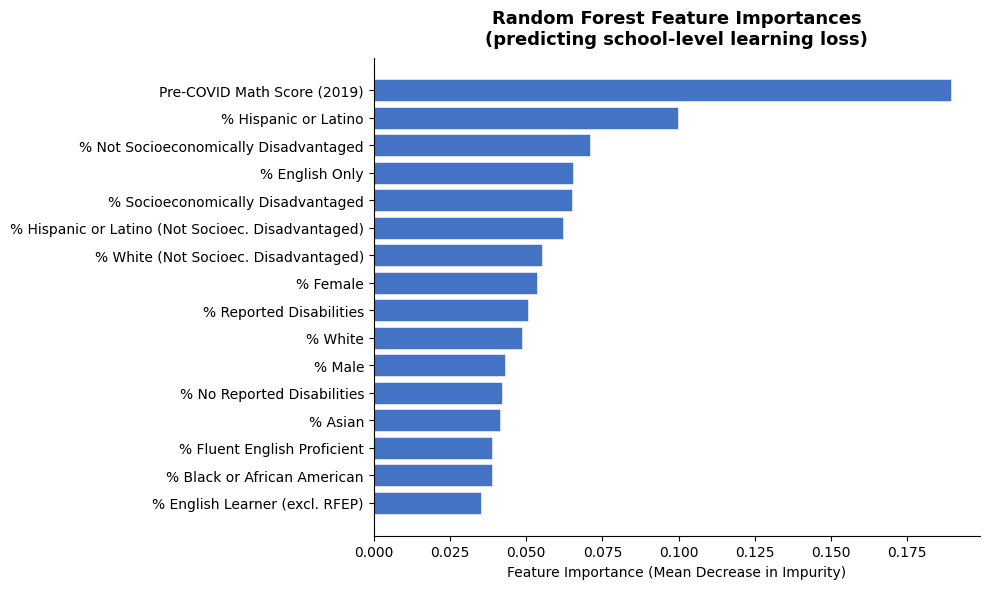

In [56]:
DEMO_LABELS = {
    "2019_128": "% Reported Disabilities",
    "2019_99":  "% No Reported Disabilities",
    "2019_31":  "% Socioeconomically Disadvantaged",
    "2019_111": "% Not Socioeconomically Disadvantaged",
    "2019_6":   "% Fluent English Proficient",
    "2019_160": "% English Learner (excl. RFEP)",
    "2019_180": "% English Only",
    "2019_76":  "% Asian",
    "2019_74":  "% Black or African American",
    "2019_78":  "% Hispanic or Latino",
    "2019_80":  "% White",
    "2019_224": "% Hispanic or Latino (Not Socioec. Disadvantaged)",
    "2019_226": "% White (Not Socioec. Disadvantaged)",
    "2019_4":   "% Female",
    "2019_3":   "% Male",
    "2019":     "Pre-COVID Math Score (2019)",
}

importances = rfr.feature_importances_
readable_labels = [DEMO_LABELS.get(f, f) for f in X.columns]
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([readable_labels[i] for i in idx], importances[idx], color="#4472C4", edgecolor="white", linewidth=0.4)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)", fontsize=10)
ax.set_title("Random Forest Feature Importances\n(predicting school-level learning loss)", fontsize=13, fontweight="bold", pad=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("feature_importances.png", dpi=150)
plt.show()

### 5.5 Residual Analysis(XGBoost)

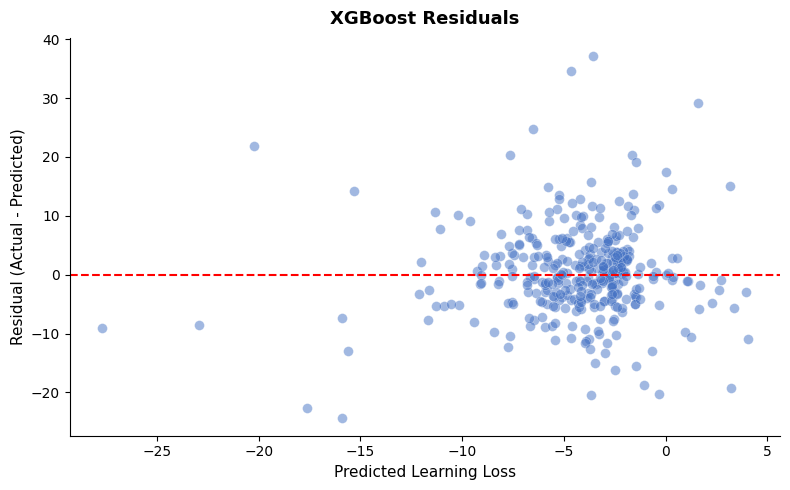

In [58]:
y_pred_xgb = xgb.predict(X_test)

residuals = y_test - y_pred_xgb

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_xgb, residuals, alpha=0.5, color="#4472C4", edgecolors="white", linewidth=0.3, s=50)
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Predicted Learning Loss", fontsize=11)
ax.set_ylabel("Residual (Actual - Predicted)", fontsize=11)
ax.set_title("XGBoost Residuals", fontsize=13, fontweight="bold", pad=10)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

Residuals fan out toward less negative predictions, indicating the model is more uncertain about schools near the average than those with severe losses. The concentration of large positive residuals -- schools the model predicted would decline but actually improved -- suggests recovery factors like district reopening policies and tutoring programs are absent from our feature set and driving the largest errors.

---
## 6. Conclusion

### Key Findings
1. The majority of Bay Area schools saw lower math scores in 2023 than 2019.
2. Demographics alone cannot reliably predict learning loss
3. Pre-COVID baseline score is the strongest predictor: schools that started higher tended to fall further.
4. Equity gaps persist: the feature importance pattern is consistent with existing research showing marginalized groups faced compounding pandemic barriers.

### Why the Models Underperform
COVID learning loss was driven by factors not captured in demographic composition:
- Instructional time lost (varied by district policy)
- Teacher shortages and turnover
- Per-pupil spending and technology access
- Individual family income shocks

### Limitations
- No 2020–21 data: testing was suspended at peak COVID
- Aggregate-level analysis: school averages mask within-school variation
- Missing data: CAASPP suppresses results for subgroups with fewer than 11 students

### Future Work
- Add instructional time, per-pupil spending, and chronic absenteeism data (all available from CDE DataQuest)
- Extend to all California counties
- Use multi-year panel modeling instead of a two-point comparison

---

### References
- [EdSource: California students struggle with math and English (2025)](https://edsource.org/2025/california-students-struggle-math-english/742613)
- [NAEP 2023 Long-Term Trend Assessment](https://www.nationsreportcard.gov/highlights/ltt/2023/)
- [EdSource: Flat test scores leave California far behind pre-COVID (2023)](https://edsource.org/2023/flat-test-scores-leave-california-far-behind-pre-covid-levels-of-achievement/698895)
- [UCSD Guardian: Academic preparedness deficiencies (2025)](https://ucsdguardian.org/2025/11/17/admissions-report-finds-academic-preparedness-deficiencies-in-incoming-ucsd-students/)
- [CAASPP Research Files: California Dept. of Education](https://www.cde.ca.gov/ta/tg/ca/caasppresearch.asp)